# 얘! clinvar도 EDA가 된단다!
- 저게 vcf파일이라 csv로 변환은 한번 했습니다... 변환하고 확인하는데 1분 걸리더군요. 저장 30초 로딩 30초...
- 근데 얘가 업데이트가 되잖아요? 그죠 나중에 새로운 파일 나오면 또 저장해야죠. 근데 주기가 그렇게 길진 않습니다. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [57]:
# 그래프 기본 테마 설정
sns.set_theme(palette="Purples_r", style="whitegrid", font_scale=1) # 블루톤

# 그래프를 그리기 위한 기본 설정
plt.rcParams['font.family'] = 'Griun Gellyroll' # 제가... 픽셀체 이런거 좋아해서...
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['axes.titlesize'] = 16 # 제목 폰트 사이즈
plt.rcParams['axes.labelsize'] = 14 # 라벨 폰트 사이즈
plt.rcParams['font.size'] = 14 # 기본 폰트사이즈
plt.rcParams['axes.unicode_minus'] = False

In [3]:
clinvar_df = pd.read_csv('data/clinvar_20260208.csv', low_memory=False)

# 데이터프레임 확인

## .shape

In [4]:
clinvar_df.shape

(4283832, 40)

## .info()

In [5]:
clinvar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4283832 entries, 0 to 4283831
Data columns (total 40 columns):
 #   Column        Dtype  
---  ------        -----  
 0   CHROM         object 
 1   POS           int64  
 2   ID            int64  
 3   REF           object 
 4   ALT           object 
 5   QUAL          object 
 6   FILTER        object 
 7   ALLELEID      int64  
 8   CLNDISDB      object 
 9   CLNDN         object 
 10  CLNHGVS       object 
 11  CLNREVSTAT    object 
 12  CLNSIG        object 
 13  CLNSIGSCV     object 
 14  CLNVC         object 
 15  CLNVCSO       object 
 16  GENEINFO      object 
 17  MC            object 
 18  ORIGIN        float64
 19  CLNVI         object 
 20  RS            object 
 21  AF_EXAC       float64
 22  AF_TGP        float64
 23  AF_ESP        float64
 24  CLNSIGCONF    object 
 25  CLNDISDBINCL  object 
 26  CLNDNINCL     object 
 27  CLNSIGINCL    object 
 28  ONC           object 
 29  ONCDISDB      object 
 30  ONCDN         obje

## .describe()

In [6]:
clinvar_df.describe(include='all')

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ALLELEID,CLNDISDB,CLNDN,...,ONCDN,ONCREVSTAT,ONCSCV,SCI,SCIDISDB,SCIDN,SCIREVSTAT,SCISCV,DBVARID,ONCCONF
count,4283832,4.283832e+06,4.283832e+06,4283832,4283832,4283832,4283832,4.283832e+06,4039201,4039201,...,1877,2545,1877,1915,1247,1247,1915,1247,153,2
unique,31,NaN,NaN,37297,20049,1,1,NaN,176228,198608,...,35,5,1877,5,291,292,4,1247,153,1
top,1,NaN,NaN,C,T,.,.,NaN,MedGen:CN169374,not_specified,...,Neoplasm,"criteria_provided,_single_submitter",SCV005094042,Tier_I_-_Strong,"Human_Phenotype_Ontology:HP:0006743,MONDO:MOND...",Embryonal_rhabdomyosarcoma,"criteria_provided,_single_submitter",SCV007104356,nsv1197537,Likely_oncogenic(1)|Uncertain_significance(1)
freq,386985,NaN,NaN,1345210,1235842,4283832,4283832,NaN,1098255,1098255,...,1697,1765,1,746,109,109,1200,1,1,2
mean,NaN,7.605171e+07,2.437123e+06,NaN,NaN,NaN,NaN,2.497208e+06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,5.763890e+07,1.324062e+06,NaN,NaN,NaN,NaN,1.383923e+06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.500000e+01,2.000000e+00,NaN,NaN,NaN,NaN,1.504100e+04,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,3.218883e+07,1.288916e+06,NaN,NaN,NaN,NaN,1.274135e+06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,6.102467e+07,2.467490e+06,NaN,NaN,NaN,NaN,2.439666e+06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1.121795e+08,3.589306e+06,NaN,NaN,NaN,NaN,3.720416e+06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## .isna().sum()

In [7]:
clinvar_df.isna().sum()

CHROM                 0
POS                   0
ID                    0
REF                   0
ALT                   0
QUAL                  0
FILTER                0
ALLELEID              0
CLNDISDB         244631
CLNDN            244631
CLNHGVS             152
CLNREVSTAT       243963
CLNSIG           243963
CLNSIGSCV        244631
CLNVC                 0
CLNVCSO               0
GENEINFO            791
MC                19948
ORIGIN             2164
CLNVI           1391400
RS              1379641
AF_EXAC         3330279
AF_TGP          3836882
AF_ESP          3871723
CLNSIGCONF      4125205
CLNDISDBINCL    4281987
CLNDNINCL       4281987
CLNSIGINCL      4281987
ONC             4281287
ONCDISDB        4281955
ONCDN           4281955
ONCREVSTAT      4281287
ONCSCV          4281955
SCI             4281917
SCIDISDB        4282585
SCIDN           4282585
SCIREVSTAT      4281917
SCISCV          4282585
DBVARID         4283679
ONCCONF         4283830
dtype: int64

- 근데 저거 다 때워야되나? 안 쓰는 칼럼들은 버려도 될 것 같은데.

## .head()

In [8]:
clinvar_df.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ALLELEID,CLNDISDB,CLNDN,...,ONCDN,ONCREVSTAT,ONCSCV,SCI,SCIDISDB,SCIDN,SCIREVSTAT,SCISCV,DBVARID,ONCCONF
0,1,66926,3385321,AG,A,.,.,3544463,"Human_Phenotype_Ontology:HP:0000547,MONDO:MOND...",Retinitis_pigmentosa,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,69134,2205837,A,G,.,.,2193183,MedGen:CN169374,not_specified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,69241,4562067,C,T,.,.,4679177,MedGen:CN169374,not_specified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,69308,3925305,A,G,.,.,4039319,MedGen:CN169374,not_specified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,69314,3205580,T,G,.,.,3374047,MedGen:CN169374,not_specified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## .columns()

In [9]:
clinvar_df.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'ALLELEID',
       'CLNDISDB', 'CLNDN', 'CLNHGVS', 'CLNREVSTAT', 'CLNSIG', 'CLNSIGSCV',
       'CLNVC', 'CLNVCSO', 'GENEINFO', 'MC', 'ORIGIN', 'CLNVI', 'RS',
       'AF_EXAC', 'AF_TGP', 'AF_ESP', 'CLNSIGCONF', 'CLNDISDBINCL',
       'CLNDNINCL', 'CLNSIGINCL', 'ONC', 'ONCDISDB', 'ONCDN', 'ONCREVSTAT',
       'ONCSCV', 'SCI', 'SCIDISDB', 'SCIDN', 'SCIREVSTAT', 'SCISCV', 'DBVARID',
       'ONCCONF'],
      dtype='object')

- 일단 쓸 칼럼 추리는게 일이겠구만...

# 전처리

## 쓸 칼럼만 추리기
- 저거 많은데 분석할 때 쓸만한게 몇개 안됩니다. 예.

### 추릴 칼럼 리스트
1. CHROM: 염색체(몇 번 염색체인지)
2. POS: 염색체 어디?
3. REF, ALT: 비포&애프터 (REF에 있는 시퀀스가 ALT로 바뀐 변이다)
4. CLNSIG: 임상적 유의성
5. CLNVC: 변이 타입(얘가 껴들어간겨 빠진겨 바뀐겨 뒤집어진겨)
6. GENEINFO: 유전자 이름+Entrez ID
7. CLNREVSTAT: 별점?

In [10]:
analysis_column = ['CHROM','POS','REF','ALT','CLNSIG','CLNVC','GENEINFO','CLNREVSTAT'] # 칼럼 뭐하는건지 위에 있어요
clinvar_df_analysis = clinvar_df[analysis_column]

clinvar_df_analysis

,CHROM,POS,REF,ALT,CLNSIG,CLNVC,GENEINFO,CLNREVSTAT
0,1,66926,AG,A,Uncertain_significance,Deletion,OR4F5:79501,"criteria_provided,_single_submitter"
1,1,69134,A,G,Likely_benign,single_nucleotide_variant,OR4F5:79501,"criteria_provided,_single_submitter"
2,1,69241,C,T,Uncertain_significance,single_nucleotide_variant,OR4F5:79501,"criteria_provided,_single_submitter"
3,1,69308,A,G,Uncertain_significance,single_nucleotide_variant,OR4F5:79501,"criteria_provided,_single_submitter"
4,1,69314,T,G,Uncertain_significance,single_nucleotide_variant,OR4F5:79501,"criteria_provided,_single_submitter"
...,...,...,...,...,...,...,...,...
4283827,NW_003315925.1,83614,TC,T,Benign,Deletion,ABO:28,"criteria_provided,_single_submitter"
4283828,NW_003315947.1,181683,C,G,Benign,single_nucleotide_variant,PECAM1:5175,no_assertion_criteria_provided
4283829,NW_003315950.2,355765,G,A,risk_factor,single_nucleotide_variant,KCNJ18:100134444,no_assertion_criteria_provided
4283830,NW_003315950.2,356212,C,T,risk_factor,single_nucleotide_variant,KCNJ18:100134444,no_assertion_criteria_provided


## 결측값 재확인

In [11]:
clinvar_df_analysis.isna().sum()
# 그러고도 결측값이 있으면 어쩌라는겁니까

CHROM              0
POS                0
REF                0
ALT                0
CLNSIG        243963
CLNVC              0
GENEINFO         791
CLNREVSTAT    243963
dtype: int64

In [12]:
# 어느놈이 비었는지 한번 보겠습니다.
clinvar_df_analysis.query('CLNSIG.isna()').index

Index([     17,      18,      19,      20,      22,      23,      24,      25,
            26,     221,
       ...
       4280700, 4280701, 4280702, 4280703, 4280704, 4280705, 4280706, 4280707,
       4280708, 4283825],
      dtype='int64', length=243963)

In [13]:
clinvar_df_analysis.loc[17]

CHROM                                 1
POS                              139320
REF                                   C
ALT                                   G
CLNSIG                              NaN
CLNVC         single_nucleotide_variant
GENEINFO               LOC729737:729737
CLNREVSTAT                          NaN
Name: 17, dtype: object

- 이거 원본 확인해보니까 진짜로 데이터가 없었습니다. 걍 언노운 처리 하면 될듯?

In [14]:
# 어느놈이 비었는지 한번 보겠습니다.
clinvar_df_analysis.query('GENEINFO.isna()').index

Index([   1927,   40672,   51138,   51139,   51140,   51141,   87239,  141269,
        141270,  141271,
       ...
       4280104, 4280105, 4280711, 4280714, 4281788, 4283409, 4283818, 4283819,
       4283820, 4283824],
      dtype='int64', length=791)

In [15]:
clinvar_df_analysis.loc[1927]

CHROM                                           1
POS                                        949925
REF                                             C
ALT                                             T
CLNSIG                                     Benign
CLNVC                   single_nucleotide_variant
GENEINFO                                      NaN
CLNREVSTAT    criteria_provided,_single_submitter
Name: 1927, dtype: object

- 이쪽도 진짜 데이터가 없는거라서 걍 때우면 될듯.

### 결측값 땜질_최종.py

In [16]:
fill_values = {
    'CLNSIG': 'Unknown_Significance',
    'CLNREVSTAT': 'No_Assertion',
    'GENEINFO': 'Unknown_Gene',
    'MC': 'Unknown_Consequence'
}

clinvar_df_analysis = clinvar_df_analysis.fillna(value=fill_values)

clinvar_df_analysis['GENE_SYMBOL'] = clinvar_df_analysis['GENEINFO'].apply(
    lambda x: x.split(':')[0] if ':' in x else x
)

In [17]:
clinvar_df_analysis

,CHROM,POS,REF,ALT,CLNSIG,CLNVC,GENEINFO,CLNREVSTAT,GENE_SYMBOL
0,1,66926,AG,A,Uncertain_significance,Deletion,OR4F5:79501,"criteria_provided,_single_submitter",OR4F5
1,1,69134,A,G,Likely_benign,single_nucleotide_variant,OR4F5:79501,"criteria_provided,_single_submitter",OR4F5
2,1,69241,C,T,Uncertain_significance,single_nucleotide_variant,OR4F5:79501,"criteria_provided,_single_submitter",OR4F5
3,1,69308,A,G,Uncertain_significance,single_nucleotide_variant,OR4F5:79501,"criteria_provided,_single_submitter",OR4F5
4,1,69314,T,G,Uncertain_significance,single_nucleotide_variant,OR4F5:79501,"criteria_provided,_single_submitter",OR4F5
...,...,...,...,...,...,...,...,...,...
4283827,NW_003315925.1,83614,TC,T,Benign,Deletion,ABO:28,"criteria_provided,_single_submitter",ABO
4283828,NW_003315947.1,181683,C,G,Benign,single_nucleotide_variant,PECAM1:5175,no_assertion_criteria_provided,PECAM1
4283829,NW_003315950.2,355765,G,A,risk_factor,single_nucleotide_variant,KCNJ18:100134444,no_assertion_criteria_provided,KCNJ18
4283830,NW_003315950.2,356212,C,T,risk_factor,single_nucleotide_variant,KCNJ18:100134444,no_assertion_criteria_provided,KCNJ18


## 돌연변이 뭐 있나?

In [18]:
clinvar_df_analysis['CLNVC'].value_counts()

CLNVC
single_nucleotide_variant    3992890
Deletion                      153849
Duplication                    65894
Microsatellite                 37962
Indel                          17835
Insertion                      13512
Inversion                       1451
Variation                        439
Name: count, dtype: int64

1. single nucleotide variant: 염기 하나가 다른 변이입니다. 대표적인 예시는 EGFR L858R. L이랑 R은 아미노산인데, 염기 하나가 바뀌어서 코돈이 변경됨->아미노산이 바뀌는겁니다. 나비효과이기도 하고 제일 잡기 어렵습니다.
2. Deletion: 염색체나 염기서열 일부가 있었는데요. 없었습니다. 있었어요. 근데 사라졌어요. ~~노쇼~~
3. Duplication: 편의점 1+1도 아니고 염색체 일부 구간이 복제되는 변이입니다.
4. Microsatellite: 게놈 전반에 걸쳐 2~7bp의 짧은 염기 서열이 반복되는 부위의 변이입니다. 음... 반복작업 하다 뻑나는건가... (처음 보는 변이임)
5. Indel: DNA를 복제할 때 염기가 첨삭되는 변이입니다.
6. Insertion: 염색체나 염기서열 일부가 끼어드는 변이입니다. ~~새치기~~
7. Inversion: 염기서열 일부가 **반대로** 들어갔습니다. DNA도 방향이 있어요 여러분...
8. Variation: 같은 종 또는 번식 집단 내 개체들 사이에서 형태, 생리, 행동 등 형질이 서로 다르게 나타나는 현상임니다. 예를 들자면 혈액형같은 게 있죠.

## CLNSIG 범주화
- 너무 많아서 묶을건 묶어야됨... 

In [19]:
clinvar_df_analysis['CLNSIG'].value_counts()

CLNSIG
Uncertain_significance                    2255754
Likely_benign                             1019961
Unknown_Significance                       243963
Benign                                     207319
Pathogenic                                 177823
                                           ...   
Uncertain_significance/VUS-high                 1
Benign|Affects|association|other                1
Benign/Likely_benign|other|risk_factor          1
Likely_benign|association                       1
VUS-high                                        1
Name: count, Length: 97, dtype: int64

In [20]:
# # 묶기 위한 조건 설정
conditions = [
    clinvar_df_analysis['CLNSIG'].str.contains('Pathogenic|Likely_pathogenic', case=False, na=False),
    clinvar_df_analysis['CLNSIG'].str.contains('Benign|Likely_benign', case=False, na=False),
    clinvar_df_analysis['CLNSIG'].str.contains('Uncertain_significance|VUS', case=False, na=False),
    clinvar_df_analysis['CLNSIG'].str.contains('Conflicting', case=False, na=False),
    clinvar_df_analysis['CLNSIG'].str.contains('risk_factor|drug_response|association|protective|Affects', case=False, na=False)
]

# 결과 그룹명
choices = ['Pathogenic', 'Benign', 'VUS', 'Conflicting', 'Risk/Other']

# 기본값은 Unknown으로 설정
clinvar_df_analysis['CLNSIG_Group'] = np.select(conditions, choices, default='Unknown')

# 결과 확인
print(clinvar_df_analysis['CLNSIG_Group'].value_counts())

CLNSIG_Group
VUS           2255940
Benign        1290605
Pathogenic     481100
Unknown        253425
Risk/Other       2762
Name: count, dtype: int64


## 염색체 범주화
- 그... 다들 무슨 말인지 아시죠?

In [40]:
def group_chrom_simple(chrom):
    # 상염색체 (1~22)
    if chrom in [str(i) for i in range(1, 23)]:
        return 'Autosome'
    # 성염색체 (X, Y)
    elif chrom in ['X', 'Y']:
        return 'Sex_Chrom'
    # 미토콘드리아
    elif chrom == 'MT':
        return 'Mitochondria'
    else:
        return 'Unknown'

clinvar_df_analysis['CHROM_Type'] = clinvar_df_analysis['CHROM'].apply(group_chrom_simple)

In [41]:
clinvar_df_analysis.to_csv('data/clinvar_20260208_analysis.csv', index=False)
# 태블로용으로 보냅니다 ㅅㄱㅇ

# 본게임 들어가자
- 근데 이거 염색체 시각화하려면 태블로 있어야겠는데...? 아니 염색체가 24개인데 그걸 한 화면에 어떻게 우겨넣습니까...

## CLNSIG으로 묶기

In [42]:
clnsig_group = clinvar_df_analysis.groupby('CLNSIG_Group')['CLNSIG_Group'].count().sort_values(ascending=False)
clnsig_group

CLNSIG_Group
VUS           2255940
Benign        1290605
Pathogenic     481100
Unknown        253425
Risk/Other       2762
Name: CLNSIG_Group, dtype: int64

- Benign: 어... 이거는요... 그... 변이인데 뭐 누구나 하나쯤은 다 갖고있는?
- VUS: 몰?루 (진짜임)

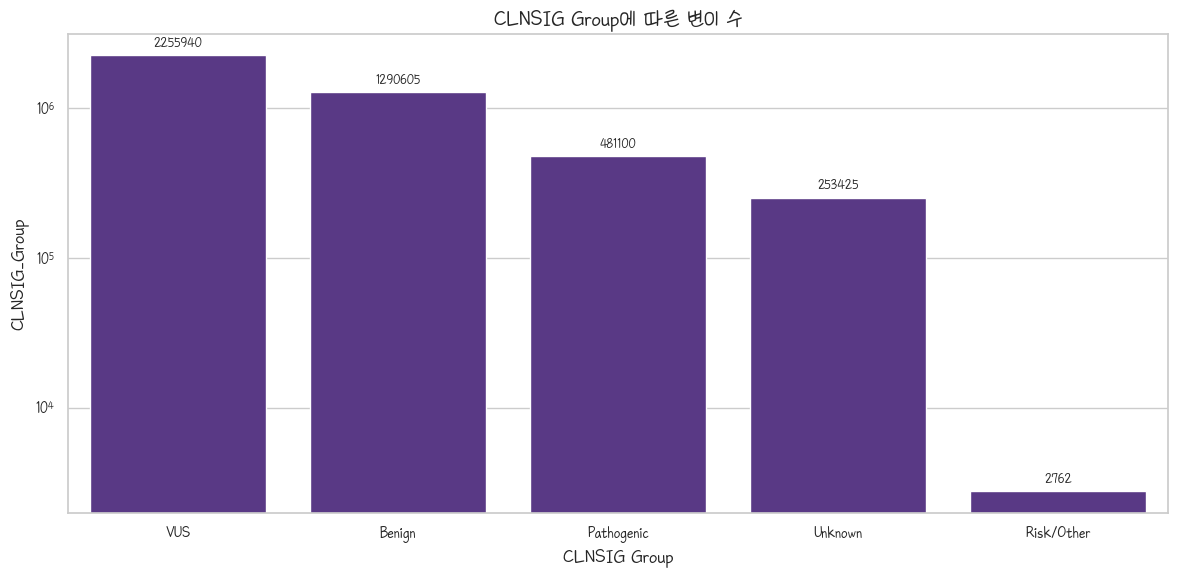

In [90]:
ax = sns.barplot(clnsig_group)

plt.title('CLNSIG Group에 따른 변이 수')
plt.xlabel('CLNSIG Group')
plt.yscale('log') # 이거 안하면 막대기 하나 안보임

for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

## 염색체-CLNSIG
- 상동염색체, 성염색체, 미토콘드리아(미토콘드리아도 지꺼 따로 있음)로 나눕니다.

In [73]:
clnsig_chr_group = clinvar_df_analysis.groupby(['CHROM_Type','CLNSIG_Group']).size().unstack().fillna(0)
clnsig_chr_group

CLNSIG_Group,Benign,Pathogenic,Risk/Other,Unknown,VUS
CHROM_Type,,,,,
Autosome,1239819.0,451198.0,2726.0,214224.0,2188927.0
Mitochondria,1629.0,192.0,3.0,34.0,1256.0
Sex_Chrom,49155.0,29710.0,30.0,39166.0,65755.0
Unknown,2.0,0.0,3.0,1.0,2.0


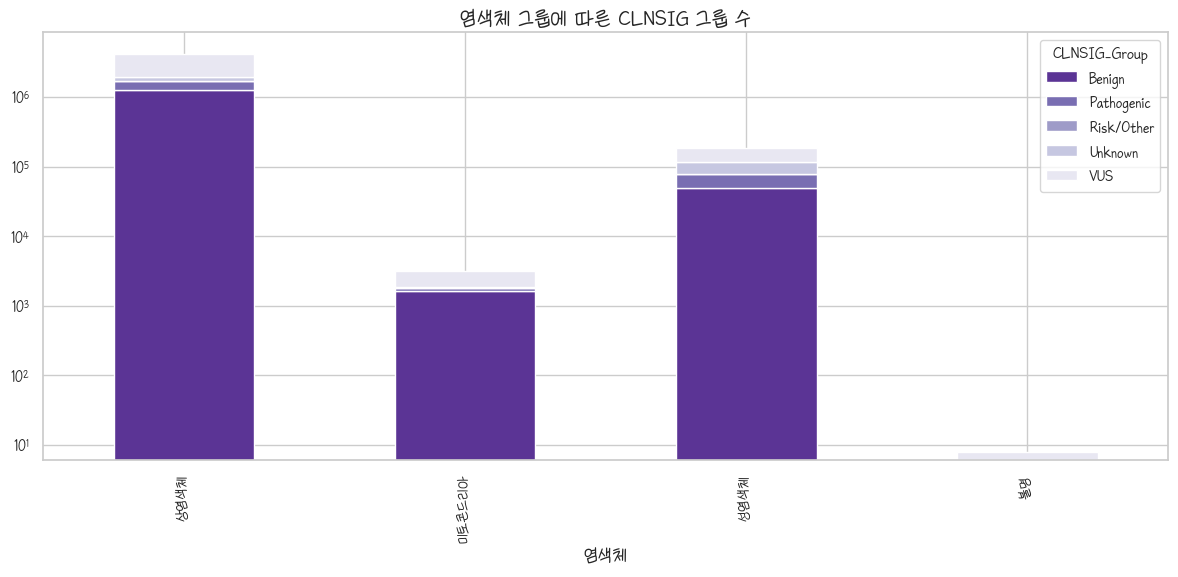

In [74]:
ax = clnsig_chr_group.plot(kind='bar', stacked=True, ax=plt.gca(), color=sns.color_palette("Purples_r", n_colors=5))
plt.title('염색체 그룹에 따른 CLNSIG 그룹 수')
plt.xlabel('염색체')
plt.xticks(ticks=[0, 1, 2, 3], labels=['상염색체','미토콘드리아','성염색체','불명'])
plt.yscale('log') # 이거 안하면 막대기 하나 안보임
plt.tight_layout()
plt.show()

- 상염색체와 미토콘드리아는 benign 다음으로 VUS가 많은데 성염색체는 benign 다음으로 비중이 뭐 거의 또이또이 쌤쌤이다. ~~쌤쌤똔똔~~

## 염색체별 변이들 중 Pathogenic의 비율은?

In [81]:
clnsig_chr_group = clinvar_df_analysis.groupby(['CHROM_Type','CLNSIG_Group']).size().unstack().fillna(0)
clnsig_chr_group['total'] = clnsig_chr_group.sum(axis=1)
clnsig_chr_group['Pathogenic rate'] = round(clnsig_chr_group['Pathogenic'] / clnsig_chr_group['total'] * 100, 2)
clnsig_chr_group

CLNSIG_Group,Benign,Pathogenic,Risk/Other,Unknown,VUS,total,Pathogenic rate
CHROM_Type,,,,,,,
Autosome,1239819.0,451198.0,2726.0,214224.0,2188927.0,4096894.0,11.01
Mitochondria,1629.0,192.0,3.0,34.0,1256.0,3114.0,6.17
Sex_Chrom,49155.0,29710.0,30.0,39166.0,65755.0,183816.0,16.16
Unknown,2.0,0.0,3.0,1.0,2.0,8.0,0.00


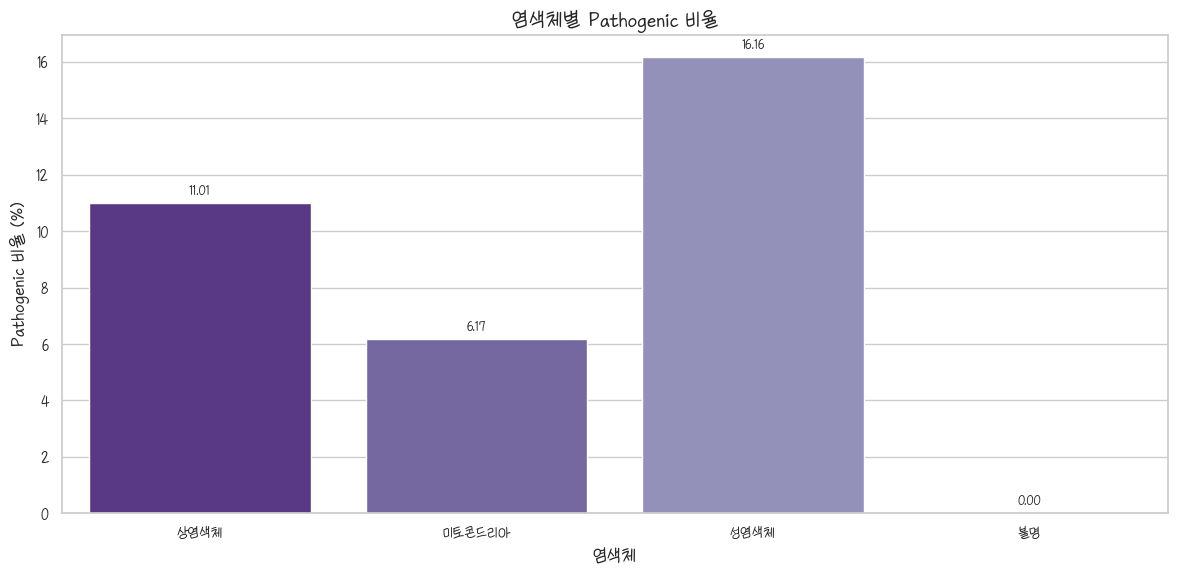

In [97]:
ax = sns.barplot(clnsig_chr_group, x = 'CHROM_Type', y = 'Pathogenic rate', hue='CHROM_Type')
plt.title('염색체별 Pathogenic 비율')
plt.xlabel('염색체')
plt.ylabel('Pathogenic 비율 (%)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['상염색체','미토콘드리아','성염색체','불명'])

for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# 얘는 로그 빼도 됩니다. 백분율이라;;
plt.tight_layout()
plt.show()